# Extensive Exploratory Data Analysis (EDA) & Churn Analytics
Comprehensive data inspection, statistical profiling, and publication-ready visualizations for Customer Churn Prediction.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global publication-ready plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('outputs/reports', exist_ok=True)

## 1. Dataset Loading & Structural Profiling

In [2]:
def load_dataset(filepath='data/Sample Dataset.csv'):
    if not os.path.exists(filepath):
        filepath = 'data/sample_data.csv'
    df = pd.read_csv(filepath)
    print(f"Loaded Dataset: {df.shape[0]:,} Rows | {df.shape[1]} Columns")
    return df

df = load_dataset()

Loaded Dataset: 71,047 Rows | 78 Columns


## 2. Target Variable & Class Imbalance Breakdown (`CHURN`)
Visualizing the proportion of churned vs retained customers.

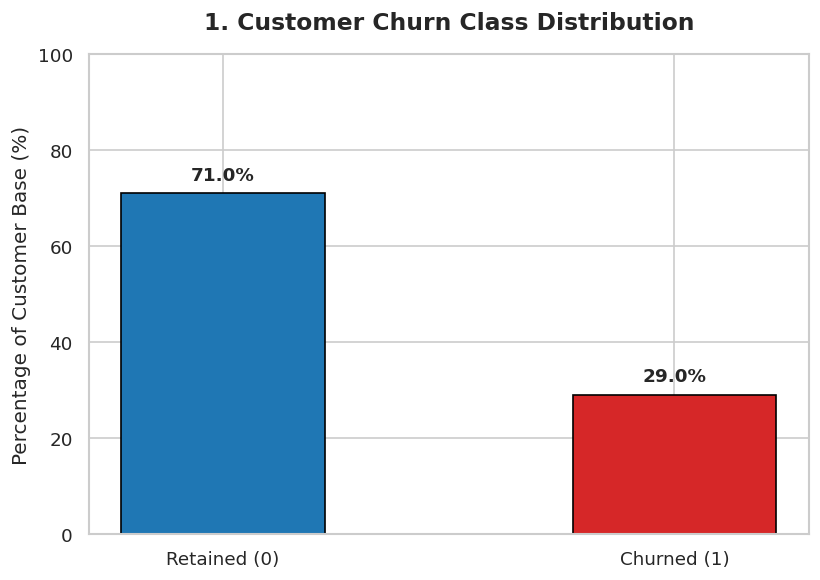

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
churn_pct = df['CHURN'].value_counts(normalize=True) * 100
bars = ax.bar(['Retained (0)', 'Churned (1)'], churn_pct, color=['#1f77b4', '#d62728'], width=0.45, edgecolor='black', linewidth=1)
ax.set_title('1. Customer Churn Class Distribution', fontweight='bold', pad=15)
ax.set_ylabel('Percentage of Customer Base (%)')
ax.set_ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('outputs/plots/viz1_churn_distribution.png', bbox_inches='tight')
plt.show()

## 3. Hardware Age & Account Tenure Impact
Comparing handset equipment age (`EQPDAYS`) and tenure (`MONTHS`) between churned and active users.

C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_4612\115013794.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHURN', y='EQPDAYS', data=df_clean, palette=['#1f77b4', '#d62728'], ax=axes[0], width=0.4, showfliers=False)
C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_4612\115013794.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])


C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_4612\115013794.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHURN', y='MONTHS', data=df_clean, palette=['#1f77b4', '#d62728'], ax=axes[1], width=0.4, showfliers=False)
C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_4612\115013794.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])


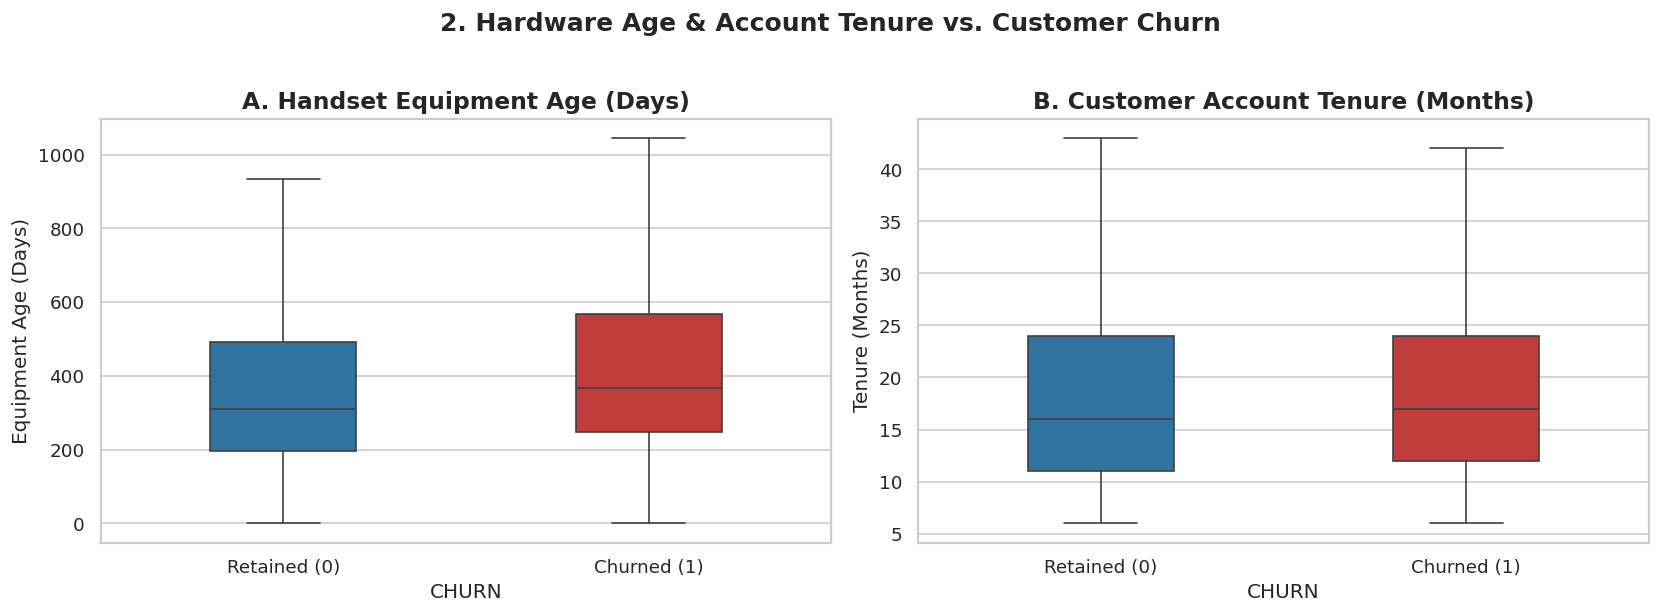

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_clean = df.copy()

if 'EQPDAYS' in df_clean.columns:
    df_clean['EQPDAYS'] = df_clean['EQPDAYS'].apply(lambda x: np.nan if x < 0 else x)
    sns.boxplot(x='CHURN', y='EQPDAYS', data=df_clean, palette=['#1f77b4', '#d62728'], ax=axes[0], width=0.4, showfliers=False)
    axes[0].set_title('A. Handset Equipment Age (Days)', fontweight='bold')
    axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
    axes[0].set_ylabel('Equipment Age (Days)')

if 'MONTHS' in df_clean.columns:
    sns.boxplot(x='CHURN', y='MONTHS', data=df_clean, palette=['#1f77b4', '#d62728'], ax=axes[1], width=0.4, showfliers=False)
    axes[1].set_title('B. Customer Account Tenure (Months)', fontweight='bold')
    axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])
    axes[1].set_ylabel('Tenure (Months)')

plt.suptitle('2. Hardware Age & Account Tenure vs. Customer Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/plots/viz2_equipment_tenure_impact.png', bbox_inches='tight')
plt.show()

## 4. Financial & Revenue Density Distributions
KDE density plots comparing Monthly Revenue (`REVENUE`) and Overage Charges (`OVERAGE`).

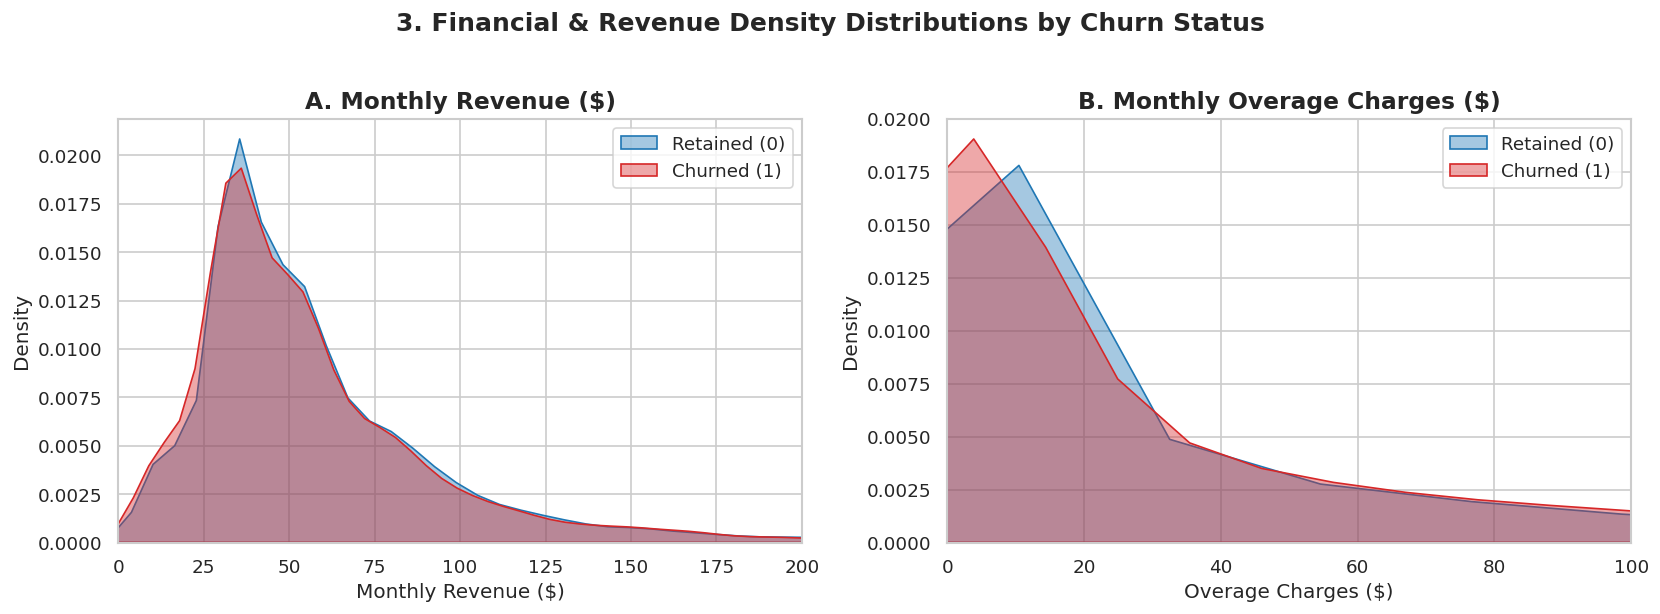

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'REVENUE' in df.columns:
    sns.kdeplot(df[df['CHURN'] == 0]['REVENUE'].dropna(), label='Retained (0)', color='#1f77b4', fill=True, ax=axes[0], alpha=0.4)
    sns.kdeplot(df[df['CHURN'] == 1]['REVENUE'].dropna(), label='Churned (1)', color='#d62728', fill=True, ax=axes[0], alpha=0.4)
    axes[0].set_title('A. Monthly Revenue ($)', fontweight='bold')
    axes[0].set_xlabel('Monthly Revenue ($)')
    axes[0].set_xlim(0, 200)
    axes[0].legend()

if 'OVERAGE' in df.columns:
    sns.kdeplot(df[df['CHURN'] == 0]['OVERAGE'].dropna(), label='Retained (0)', color='#1f77b4', fill=True, ax=axes[1], alpha=0.4)
    sns.kdeplot(df[df['CHURN'] == 1]['OVERAGE'].dropna(), label='Churned (1)', color='#d62728', fill=True, ax=axes[1], alpha=0.4)
    axes[1].set_title('B. Monthly Overage Charges ($)', fontweight='bold')
    axes[1].set_xlabel('Overage Charges ($)')
    axes[1].set_xlim(0, 100)
    axes[1].legend()

plt.suptitle('3. Financial & Revenue Density Distributions by Churn Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/plots/viz3_financial_distributions.png', bbox_inches='tight')
plt.show()

## 5. Network Quality & Service Friction Drivers
Evaluating dropped voice calls (`DROPVCE`) and blocked calls (`BLCKVCE`).

C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_4612\1716243711.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CHURN', y='DROPVCE', data=df, palette=['#1f77b4', '#d62728'], ax=axes[0], errorbar=None, width=0.45, edgecolor='black')
C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_4612\1716243711.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_4612\1716243711.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CHURN', y='BLCKVCE', data=df, palette=['#1f77b4', '#d62728'], ax=axes[1], er

C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_4612\1716243711.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])


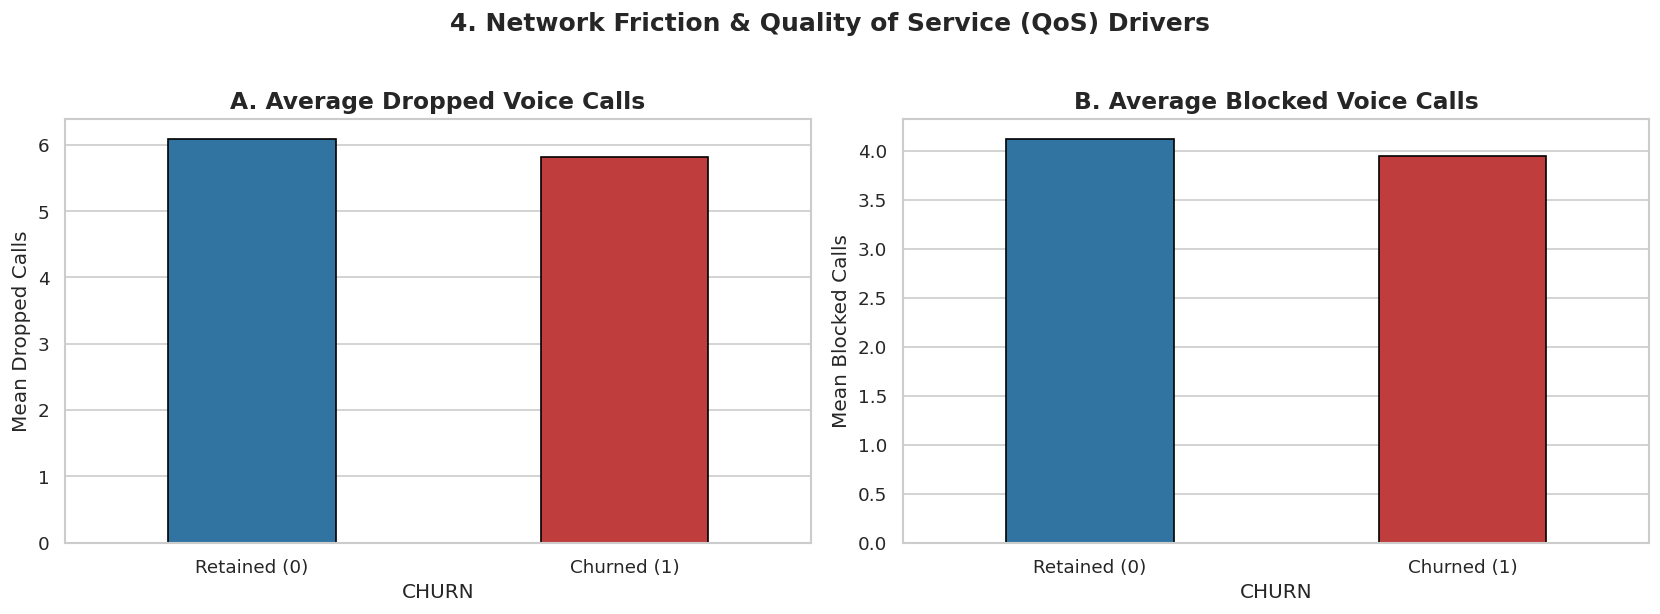

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'DROPVCE' in df.columns:
    sns.barplot(x='CHURN', y='DROPVCE', data=df, palette=['#1f77b4', '#d62728'], ax=axes[0], errorbar=None, width=0.45, edgecolor='black')
    axes[0].set_title('A. Average Dropped Voice Calls', fontweight='bold')
    axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
    axes[0].set_ylabel('Mean Dropped Calls')

if 'BLCKVCE' in df.columns:
    sns.barplot(x='CHURN', y='BLCKVCE', data=df, palette=['#1f77b4', '#d62728'], ax=axes[1], errorbar=None, width=0.45, edgecolor='black')
    axes[1].set_title('B. Average Blocked Voice Calls', fontweight='bold')
    axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])
    axes[1].set_ylabel('Mean Blocked Calls')

plt.suptitle('4. Network Friction & Quality of Service (QoS) Drivers', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/plots/viz4_qos_service_friction.png', bbox_inches='tight')
plt.show()

## 6. Comprehensive Feature Correlation Matrix
Heatmap of Pearson correlation coefficients across key features and target.

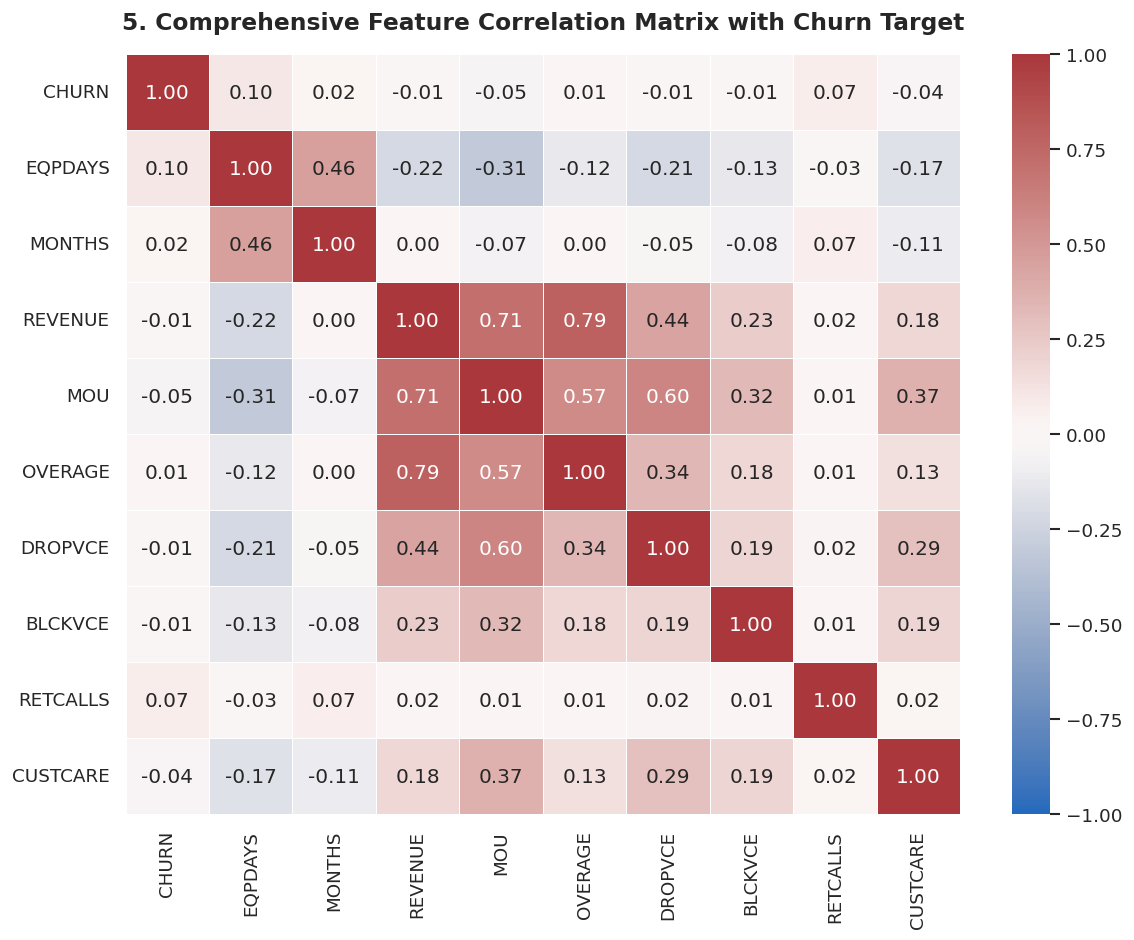

In [7]:
target_cols = ['CHURN', 'EQPDAYS', 'MONTHS', 'REVENUE', 'MOU', 'OVERAGE', 
               'DROPVCE', 'BLCKVCE', 'RETCALLS', 'CUSTCARE']
available_cols = [c for c in target_cols if c in df.columns]
corr = df[available_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('5. Comprehensive Feature Correlation Matrix with Churn Target', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/plots/viz6_correlation_heatmap.png', bbox_inches='tight')
plt.show()